# Project Pt. 3: NBA Salaries Aren’t About Efficiency: The Roles of Age, Experience, and Scoring Variability (1950–2023)

## Team Members
- Ashley Kang (ashleykg)
- Min-Yi Chen (minyi)
- Chloe Yueh (yyueh)

## 0. Import packages

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


## 1. Preprocessing Data

### 1.1 Data Import and Initial Cleaning
In this section, we import the merged dataset and prepare it for machine learning. Our cleaning process involves:
1. Dropping irrelevant identification columns (e.g., player names).
2. Identifying and handling missing values.
3. Removing duplicate rows.
4. Addressing data inconsistencies (e.g., ensuring percentages are within valid ranges).
5. Creating a derived feature (`PTS_per_game`) to better represent a player's scoring impact regardless of the total games played.

In [2]:
# Import the dataset
df = pd.read_csv('merged_data.csv')
print("=" * 60)
print(f"Original dataset shape : {df.shape}")
print("=" * 60)
# print(df.head(3))

# Drop irrelevant columns (player names are not useful for ML prediction)
columns_to_drop = ['player']
df_cleaned = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

# Handle missing values
# check how many missing values exist
missing_count = df_cleaned.isnull().sum().sum()
print("\n[Missing Values]")
print(f"Total missing values   : {missing_count}")
if missing_count == 0:
    print("No missing values found. No imputation needed.")
else:
    print(f"Found {missing_count} missing values. Handling required.")
    df_cleaned = df_cleaned.fillna(df_cleaned.median(numeric_only=True))
# Since missing count is 0, no dropna() or imputation is needed!

duplicate_count = df_cleaned.duplicated().sum()
print("\n[Duplicate Rows]")
print(f"Total duplicate rows   : {duplicate_count}")

if duplicate_count > 0:
    df_cleaned = df_cleaned.drop_duplicates().copy()
    print(f"Shape after removing duplicates: {df_cleaned.shape}\n")
else:
    print("No duplicate rows found.\n")

# Handle inconsistencies
# Ensure percentages (like FG%) are between 0 and 1 and games played (G) is greater than 0.
# This prevents extreme outliers or data entry errors from skewing the model
df_cleaned = df_cleaned[
    df_cleaned['FG%'].between(0, 1)
    & df_cleaned['FT%'].between(0, 1)
    & (df_cleaned['G'] > 0)
].copy()

# Feature engineering: create 'PTS_per_game'
# Total points can be misleading if a player played very few games. 
# Points per game is a more standardized metric for evaluating performance.
if 'PTS' in df_cleaned.columns and 'G' in df_cleaned.columns:
    df_cleaned['PTS_per_game'] = df_cleaned['PTS'] / df_cleaned['G']

print('\n' + '=' * 60)
print('Cleaning Summary')
print(f"Final dataset shape    : {df_cleaned.shape}")
print('=' * 60)
print('\nCheck data types and non-null counts after cleaning:')
df_cleaned.info()
print()
df_cleaned.head()

Original dataset shape : (13604, 17)

[Missing Values]
Total missing values   : 0
No missing values found. No imputation needed.

[Duplicate Rows]
Total duplicate rows   : 518
Shape after removing duplicates: (13086, 16)


Cleaning Summary
Final dataset shape    : (13086, 17)

Check data types and non-null counts after cleaning:
<class 'pandas.core.frame.DataFrame'>
Index: 13086 entries, 0 to 13602
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   season              13086 non-null  int64  
 1   Pos                 13086 non-null  object 
 2   Age                 13086 non-null  float64
 3   Tm                  13086 non-null  object 
 4   G                   13086 non-null  float64
 5   GS                  13086 non-null  float64
 6   MP                  13086 non-null  float64
 7   FG                  13086 non-null  float64
 8   FGA                 13086 non-null  float64
 9   FG%                 1

,season,Pos,Age,Tm,G,GS,MP,FG,FGA,FG%,FT,FTA,FT%,PTS,salary,inflationAdjSalary,PTS_per_game
0,1990,C,27.0,ORL,80.0,50.0,1691.0,138.0,285.0,0.484211,83.0,120.0,0.691667,362.0,437000.0,996827.0,4.525000
1,1990,PG,27.0,DEN,79.0,74.0,2690.0,398.0,989.0,0.402427,267.0,314.0,0.850318,1221.0,825000.0,1881882.0,15.455696
2,1990,SF,30.0,DET,78.0,40.0,2005.0,438.0,898.0,0.487751,192.0,254.0,0.755906,1099.0,1115000.0,2543393.0,14.089744
3,1990,PG,30.0,SAC,75.0,68.0,2727.0,506.0,1154.0,0.438475,222.0,267.0,0.831461,1342.0,725000.0,1653775.0,17.893333
4,1990,PF,26.0,WSB,82.0,10.0,1893.0,371.0,785.0,0.472611,108.0,133.0,0.812030,860.0,500000.0,1140535.0,10.487805


The initial cleaning process successfully streamlined our dataset. By dropping the `player` column, we removed a non-predictive identifier that would not be meaningful for machine learning. Our missing value check confirmed 0 missing entries. In the current merged dataset, no columns contained missing values, so no imputation or row removal was necessary at this stage. However, we identified and removed 518 duplicate rows to prevent the model from overfitting to repeated observations.

Next, we addressed basic data consistency by ensuring that percentage-based variables such as `FG%` remained within the valid range of 0 to 1. This step helps protect the model from impossible values caused by data-entry errors or data-merging issues. Finally, we engineered a new feature, `PTS_per_game`, to better represent scoring productivity on a per-game basis. This derived variable is more informative than raw total points alone because it accounts for differences in the number of games played.

### 1.2 Encoding, Splitting & Scaling

To prepare our data for classification, we must strictly avoid data leakage. Therefore, we perform the train-test split *before* any scaling or encoding. Our process includes:
1. **Target Definition:** We convert the continuous `inflationAdjSalary` into a categorical target (`Salary_Tier`) with three balanced classes: Low, Mid, and High, using quantile-based discretization (`pd.qcut`).
2. **Train-Test Split:** We set aside 20% of our data for testing to evaluate our models on unseen data later.
3. **ColumnTransformer Pipeline:** Following best practices from class, we use `sklearn.compose.ColumnTransformer` to apply `StandardScaler` to all numerical features (preventing magnitude bias) and `OneHotEncoder` to categorical features (`Pos`, `Tm`). This ensures transformations are fitted solely on the training data.

In [3]:
# Define Target Label: Split salary into 3 equal-sized tiers (Low, Mid, High)
df_cleaned['Salary_Tier'] = pd.qcut(df_cleaned['inflationAdjSalary'], q=3, labels=['Low', 'Mid', 'High'])

# Define Features (X) and Target (y)
# Drop the target columns and any raw salary columns to prevent the model from cheating
# We also exclude season so that the model focuses on player-level attributes and performance rather than learning era-specific salary patterns.
X = df_cleaned.drop(columns=['salary', 'inflationAdjSalary', 'Salary_Tier', 'season'])
y = df_cleaned['Salary_Tier']

# Check class balance before splitting
print("Class distribution in full dataset:")
print(y.value_counts())
print("\nClass proportions in full dataset:")
print((y.value_counts(normalize=True)).round(3))

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"\nTraining set size: {X_train.shape[0]} rows")
print(f"Testing set size: {X_test.shape[0]} rows\n")

print("Training set class proportions:")
print((y_train.value_counts(normalize=True)).round(3))

print("\nTesting set class proportions:")
print((y_test.value_counts(normalize=True)).round(3))

# Separate column names by type
numeric_features = ['Age', 'G', 'GS', 'MP', 'FG', 'FGA', 'FG%', 'FT', 'FTA', 'FT%', 'PTS', 'PTS_per_game']
categorical_features = ['Pos', 'Tm']

# Create ColumnTransformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

# Fit and Transform on Training set, ONLY Transform on Testing set
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"\nFeatures before encoding: {X_train.shape[1]}")
print(f"Features after ColumnTransformer (Scaling + One-Hot): {X_train_processed.shape[1]}")

feature_names = preprocessor.get_feature_names_out()
# Convert the processed training features back to a DataFrame for better visualization
X_train_df = pd.DataFrame(X_train_processed, columns=feature_names)

print("\nDataFrame after ColumnTransformer processing (first 3 rows):")
X_train_df.head(3)

Class distribution in full dataset:
Salary_Tier
Low     4362
Mid     4362
High    4362
Name: count, dtype: int64

Class proportions in full dataset:
Salary_Tier
Low     0.333
Mid     0.333
High    0.333
Name: proportion, dtype: float64

Training set size: 10468 rows
Testing set size: 2618 rows

Training set class proportions:
Salary_Tier
High    0.333
Low     0.333
Mid     0.333
Name: proportion, dtype: float64

Testing set class proportions:
Salary_Tier
Low     0.333
Mid     0.333
High    0.333
Name: proportion, dtype: float64

Features before encoding: 14
Features after ColumnTransformer (Scaling + One-Hot): 67

DataFrame after ColumnTransformer processing (first 3 rows):


,num__Age,num__G,num__GS,num__MP,num__FG,num__FGA,num__FG%,num__FT,num__FTA,num__FT%,...,cat__Tm_POR,cat__Tm_SAC,cat__Tm_SAS,cat__Tm_SEA,cat__Tm_TOR,cat__Tm_TOT,cat__Tm_UTA,cat__Tm_VAN,cat__Tm_WAS,cat__Tm_WSB
0,0.545691,-2.095541,-0.918118,-1.389845,-1.092193,-1.144331,1.653058,-0.825237,-0.864581,0.356744,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-0.670933,-0.533584,-0.952702,-0.920680,-0.843854,-0.842436,-0.292391,-0.638195,-0.710124,1.070426,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,-0.670933,-0.027003,-0.814365,-0.493547,-0.653268,-0.627574,-0.324718,-0.507265,-0.563021,0.628361,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


The dataset was successfully split into 10468 training samples and 2618 testing samples. Before splitting, we converted `inflationAdjSalary` into a categorical target variable, `Salary_Tier`, using quantile-based discretization. This created three nearly equal-sized classes: Low, Mid, and High, each representing about one-third of the dataset. By using `stratify=y` during the train-test split, we preserved this balanced class distribution in both the training and testing sets.

Next, we applied a `ColumnTransformer` to preprocess the features in a way that avoids data leakage. All numerical variables were standardized using `StandardScaler`, while the categorical variables `Pos` and `Tm` were transformed using `OneHotEncoder`. This process expanded the feature space from 14 original features to 67 processed features. This preprocessing step ensures that the dataset is both machine-readable and appropriately scaled for modeling.

### 1.3 Dimensionality Reduction

With 67 features after One-Hot Encoding, our dataset might suffer from the curse of dimensionality, introducing noise and increasing computation time. To address this, we apply Principal Component Analysis (PCA).

We will first fit a full PCA to visualize the Explained Variance Ratio (EVR) using a Scree Plot. Based on the cumulative variance, we will determine the optimal number of principal components to retain before transforming our train and test sets.

Explained variance ratio (first 10 components):
  PC1: 0.560
  PC2: 0.087
  PC3: 0.074
  PC4: 0.056
  PC5: 0.049
  PC6: 0.026
  PC7: 0.018
  PC8: 0.015
  PC9: 0.014
  PC10: 0.013


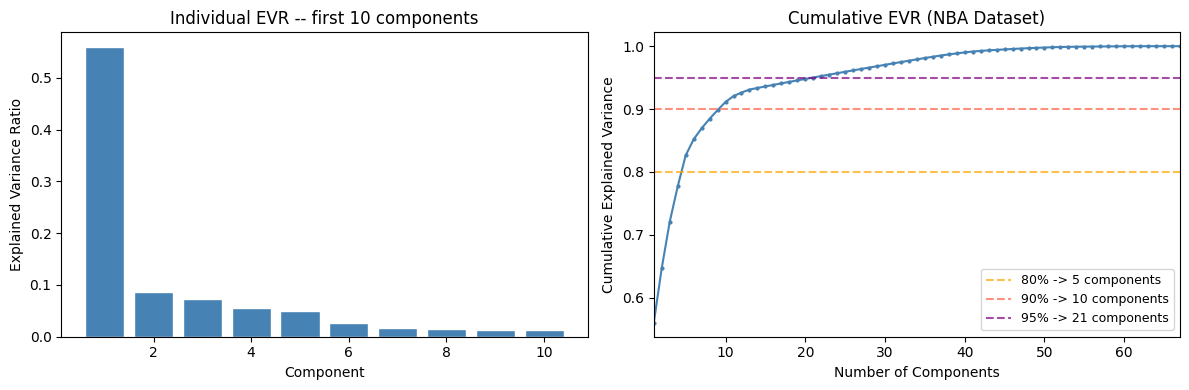

Components to reach 80%: 5
Components to reach 90%: 10
Components to reach 95%: 21

Final training set shape after PCA: (10468, 10)
Final testing set shape after PCA: (2618, 10)


In [4]:
# Fit PCA on the fully processed training set (all 67 components)
pca_full_nba = PCA(random_state=42)
pca_full_nba.fit(X_train_processed) # X_train_processed is already scaled from Step 1.2

print("Explained variance ratio (first 10 components):")
for i, evr in enumerate(pca_full_nba.explained_variance_ratio_[:10], 1):
    print(f"  PC{i}: {evr:.3f}")

# Scree plot
cumvar_nba = np.cumsum(pca_full_nba.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Individual EVR
axes[0].bar(range(1, 11), pca_full_nba.explained_variance_ratio_[:10],
            color='steelblue', edgecolor='white')
axes[0].set_xlabel('Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Individual EVR -- first 10 components')

# Cumulative EVR
axes[1].plot(range(1, len(cumvar_nba)+1), cumvar_nba, marker='.', ms=4, color='steelblue')
# Add horizontal lines for common variance thresholds
for threshold, color in [(0.80, 'orange'), (0.90, 'tomato'), (0.95, 'purple')]:
    n = np.argmax(cumvar_nba >= threshold) + 1
    axes[1].axhline(threshold, color=color, linestyle='--', alpha=0.7,
                    label=f'{threshold:.0%} -> {n} components')

axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative EVR (NBA Dataset)')
axes[1].legend(fontsize=9)
axes[1].set_xlim(1, 67) # We have 67 features in total

plt.tight_layout()
plt.show()

# Print the number of components needed for common thresholds
print(f"Components to reach 80%: {np.argmax(cumvar_nba >= 0.80)+1}")
print(f"Components to reach 90%: {np.argmax(cumvar_nba >= 0.90)+1}")
print(f"Components to reach 95%: {np.argmax(cumvar_nba >= 0.95)+1}")

# Final Transformation: We choose to keep 90% of the variance
n_components_90 = np.argmax(cumvar_nba >= 0.90) + 1
pca_final = PCA(n_components=n_components_90, random_state=42)

# Fit & Transform on Train, ONLY Transform on Test
X_train_pca = pca_final.fit_transform(X_train_processed)
X_test_pca = pca_final.transform(X_test_processed)

print(f"\nFinal training set shape after PCA: {X_train_pca.shape}")
print(f"Final testing set shape after PCA: {X_test_pca.shape}")

Looking at the scree plot, it’s clear that keeping all 67 features is unnecessary. We noticed a sharp drop-off in explained variance after the first few components. Reaching 90% explained variance only takes 10 components, but pushing that to 95% would require 21 components.

**Why we chose the 90% threshold:**
We decided to cap the variance at 90% (keeping 10 components) because it offers the best trade-off between retaining useful information and reducing model complexity. If we went for 95%, we would have to more than double our feature count just to capture an extra 5% of variance. In the context of our NBA dataset, that final 5% likely reflects lower-importance variation, sparse team-specific dummy variables, or other highly specific patterns that may not meaningfully improve salary-tier prediction.

**How this helps modeling:**
By compressing our dataset down to these 10 core principal components, PCA reduced redundancy among features and transformed the data into orthogonal components, which helps simplify the feature space for downstream modeling. More importantly, reducing the dimensionality means the models we build next are less likely to focus on noisy or overly specific patterns in the training data. This should make the models more efficient and may also help reduce overfitting.


### 1.4 PCA Loadings and 2D Projection Visualization

Now that we have our principal components, we need to figure out what they actually mean. We can do this by looking at the feature loadings, which show which of our original NBA stats have the biggest influence on each new component. After that, we'll plot the first two components (PC1 and PC2) on a 2D scatter plot. This gives us a quick visual sanity check to see if the different salary tiers (Low, Mid, High) are naturally separating before we even start building our classification models.

--- Top 5 Positive Drivers for PC1 ---
num__PTS    0.356028
num__FG     0.353747
num__FGA    0.351589
num__MP     0.340984
num__FT     0.333929
Name: PC1, dtype: float64

--- Top 5 Positive Drivers for PC2 ---
num__FT%             0.673329
num__Age             0.322823
cat__Pos_PG          0.098058
num__PTS_per_game    0.089707
cat__Pos_SG          0.081519
Name: PC2, dtype: float64


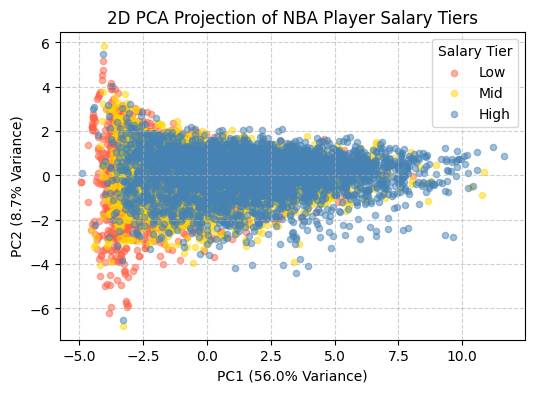

In [5]:
# Visualize PC1 & PC2 Loadings (Identifying what the components represent)
# We use the feature names we extracted earlier
loadings = pd.DataFrame(
    pca_final.components_.T,
    index=feature_names,
    columns=[f'PC{i}' for i in range(1, n_components_90 + 1)]
)

print("--- Top 5 Positive Drivers for PC1 ---")
print(loadings['PC1'].sort_values(ascending=False).head(5))

print("\n--- Top 5 Positive Drivers for PC2 ---")
print(loadings['PC2'].sort_values(ascending=False).head(5))

# 2D PCA Projection Visualization
# We only use PC1 and PC2 for the plot because we can't see 10D
plt.figure(figsize=(6, 4))
colors = {'Low': 'tomato', 'Mid': 'gold', 'High': 'steelblue'}

for tier in ['Low', 'Mid', 'High']:
    mask = (y_train == tier).values
    plt.scatter(X_train_pca[mask, 0], X_train_pca[mask, 1], 
                label=tier, alpha=0.5, c=colors[tier], s=20)

plt.xlabel(f'PC1 ({pca_final.explained_variance_ratio_[0]:.1%} Variance)')
plt.ylabel(f'PC2 ({pca_final.explained_variance_ratio_[1]:.1%} Variance)')
plt.title('2D PCA Projection of NBA Player Salary Tiers')
plt.legend(title="Salary Tier")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Looking at the loadings, the components actually make a lot of basketball sense. The strongest positive loadings on PC1 are volume-based scoring and playing-time variables like PTS, FG, FGA, and MP. So, we can essentially think of PC1 as a player's overall offensive output & playing time. On the other hand, **PC2** is heavily influenced by FT%, Age, and guard positions (Pos_PG, Pos_SG), which feels more like a measure of veteran & guard shooting efficiency.

When we look at the 2D scatter plot, the salary tiers definitely overlap, but there’s a clear trend. The players in the **High** salary tier stretch far out to the right (meaning they have a high PC1 / high offensive output), while the **Low** salary tier players are mostly clustered on the left.

The messy overlap in the middle isn't a problem with our PCA; it actually captures how complicated NBA salaries are in real life. For example, you have young star players still stuck on cheap rookie contracts (which means high offensive output but low salary), or older veterans making minimum wage. These real-world situations naturally blur the lines between our salary tiers. This plot suggests that our PCA components captured meaningful patterns related to salary, even with the natural unpredictability of sports contracts.

### 1.5 Preprocessing justification and impact analysis

**1.1 Data Import and Initial Cleaning**  
We dropped identifiers like player names because they function as labels rather than meaningful predictive features for unseen data. We also removed 518 duplicate rows to ensure the model does not memorize repeated data points. We applied filters to exclude any rows with impossible percentage values or non-positive games played. In the current merged dataset, no rows were removed by this step. Adding the `PTS_per_game` feature was necessary because raw total points are strongly influenced by how many games a player played. This new feature gives the models a more standardized measure of scoring impact.

**1.2 Encoding, Splitting & Scaling**  
Splitting the data into train and test sets before doing any scaling or encoding was our most important decision to prevent data leakage. We used `StandardScaler` for all numerical columns. This is especially important because models such as SVM are sensitive to feature scale, and PCA is also variance-based. Without scaling, a feature with large raw values like total points could dominate a feature with smaller ranges like shooting percentage. We used `OneHotEncoder` to convert categorical variables (`Tm` and `Pos`) into a format the models can process.

**1.3 Dimensionality Reduction (PCA)**  
One-hot encoding expanded our dataset to 67 features, which increased dimensionality and introduced more redundancy into the feature space. We used PCA to compress these 67 transformed features into 10 principal components. We stopped at 10 components because they capture 90% of the variance. Pushing to 95% would require 21 components, meaning we would more than double the number of retained components just to capture an additional 5% of variance, which likely reflects lower-importance variation or highly specific patterns.

**1.4 PCA Loadings and 2D Projection**  
Looking at the loadings showed that the PCA components were interpretable, with PC1 capturing volume scoring and playing time, and PC2 reflecting a mix of shooting efficiency, age, and guard-related profile features.

By transforming the processed data into these 10 orthogonal principal components derived from scaled input features, the downstream classifiers may train more efficiently in a lower-dimensional feature space. More importantly, by reducing redundancy and compressing highly specific variation from the expanded feature set, the models may be less likely to overfit the training data. This helps make the later evaluation on the unseen test set more credible, because the models will be trained on features that are cleaner, more comparable in scale, and less redundant.

## 2. Clustering or Classification Analysis (Ashley)

### 2.1 Analytical Goal and Rationale
*(Clearly define the goal, explain the choice of clustering or classification, and connect features to research questions)*

### 2.2 Model Implementation
*(If Classification: Define target label (e.g., salary tiers), implement at least two classifiers like Random Forest/SVM)*
*(If Clustering: Implement k-Means and Agglomerative Clustering, try different cluster numbers)*

### 2.3 Parameter Optimization
*(If Classification: GridSearchCV with cross-validation)*
*(If Clustering: Elbow Method, Silhouette Score)*

### 2.4 Performance Evaluation
*(If Classification: Accuracy, Precision, Recall, F1-Score, Confusion Matrix)*
*(If Clustering: Visualize clusters, Silhouette Score, cluster profiling)*

## 3. Interpretation and Final Reporting (Member 3 - Chloe)

### 3.1 Interpretation and Discussion of Results
*(Analyze results deeply: feature importance or cluster meanings. Discuss preprocessing impacts. Connect back to Part 1 & 2 insights on scoring/salary. Discuss limitations)*

### 3.2 Code and Reporting Quality Check
*(Ensure PEP-8 compliance, proper grammar/spelling, professional language, and error-free "Run All" execution)*